In [1]:
!pip install tokenizers datasets tqdm

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pandas as pd

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

In [3]:
DATA_X = "inputx_dev.txt"
DATA_Y = "inputy_dev.txt"

with open(DATA_X, encoding="utf8") as f:
    input_x = [l.strip() for l in f]

with open(DATA_Y, encoding="utf8") as f:
    input_y = [l.strip() for l in f]

split = int(0.8 * len(input_x))

train_x = input_x[:split]
train_y = input_y[:split]

test_x = input_x[split:]
test_y = input_y[split:]

print("Train size:", len(train_x))
print("Test size:", len(test_x))

Train size: 69470
Test size: 17368


In [4]:
print(train_x[11])
print(train_y[11])

नाम
नाम


In [5]:
special_tokens = ["<pad>", "<bos>", "<eos>", "<unk>"]

tokenizer = Tokenizer(BPE(unk_token="<unk>"))
tokenizer.pre_tokenizer = Whitespace()

trainer = BpeTrainer(
    vocab_size=8000,
    special_tokens=special_tokens
)

tokenizer.train_from_iterator(train_x + train_y, trainer)

vocab_size = tokenizer.get_vocab_size()

PAD_IDX = tokenizer.token_to_id("<pad>")
BOS_IDX = tokenizer.token_to_id("<bos>")
EOS_IDX = tokenizer.token_to_id("<eos>")
UNK_IDX = tokenizer.token_to_id("<unk>")

print("PAD index:", PAD_IDX)

PAD index: 0


In [42]:
MAX_LEN = 16
def encode(text):

    ids = tokenizer.encode(text).ids
    ids = [BOS_IDX] + ids + [EOS_IDX]

    if len(ids) < MAX_LEN:
        ids += [PAD_IDX]*(MAX_LEN-len(ids))
    else:
        ids = ids[:MAX_LEN]

    return ids

In [7]:
class OCRDataset(Dataset):

    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):

        src = torch.tensor(encode(self.inputs[idx]), dtype=torch.long)
        tgt = torch.tensor(encode(self.targets[idx]), dtype=torch.long)

        return src, tgt

In [41]:
from torch.utils.data import random_split

dataset = OCRDataset(train_x, train_y)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 869
Validation batches: 218


In [40]:
lengths = [len(tokenizer.encode(w).ids) for w in train_x]
import numpy as np
print("Max:", max(lengths))
print("95th percentile:", np.percentile(lengths, 95))
print("Mean:", np.mean(lengths))

Max: 33
95th percentile: 7.0
Mean: 2.6193464804951776


In [9]:
class RMSNorm(nn.Module):

    def __init__(self, d_model, eps=1e-8):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))
        self.eps = eps

    def forward(self, x):

        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)

        return self.scale * x / rms

In [10]:
class pRMSNorm(nn.Module):

    def __init__(self, d_model, p=0.1, eps=1e-8):
        super().__init__()

        self.scale = nn.Parameter(torch.ones(d_model))
        self.p = p
        self.eps = eps

    def forward(self, x):

        d = x.size(-1)
        k = max(1, int(self.p * d))
        partial = x[..., :k]  # Always use first k dimensions, not random
        rms = torch.sqrt(torch.mean(partial**2, dim=-1, keepdim=True) + self.eps)
        return self.scale * x / rms

In [11]:
def get_norm(norm_type, d_model):

    if norm_type == "layer":
        return nn.LayerNorm(d_model)

    elif norm_type == "rms":
        return RMSNorm(d_model)

    elif norm_type == "prms6":
        return pRMSNorm(d_model, p=0.0625)

    elif norm_type == "prms10":
        return pRMSNorm(d_model, p=0.10)

In [12]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2)*(-math.log(10000)/d_model))

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self,x):

        return x + self.pe[:,:x.size(1)]

In [13]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_k = d_model//num_heads
        self.num_heads = num_heads

        self.W_q = nn.Linear(d_model,d_model)
        self.W_k = nn.Linear(d_model,d_model)
        self.W_v = nn.Linear(d_model,d_model)

        self.W_o = nn.Linear(d_model,d_model)

    def scaled_dot_product_attention(self,Q,K,V,mask=None):

        scores = torch.matmul(Q,K.transpose(-2,-1))/math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask==0,-1e9)

        attn = F.softmax(scores,dim=-1)

        return torch.matmul(attn,V)

    def forward(self,Q,K,V,mask=None):

        batch = Q.size(0)

        Q = self.W_q(Q).view(batch,-1,self.num_heads,self.d_k).transpose(1,2)
        K = self.W_k(K).view(batch,-1,self.num_heads,self.d_k).transpose(1,2)
        V = self.W_v(V).view(batch,-1,self.num_heads,self.d_k).transpose(1,2)

        context = self.scaled_dot_product_attention(Q,K,V,mask)

        context = context.transpose(1,2).contiguous().view(batch,-1,self.num_heads*self.d_k)

        return self.W_o(context)

In [43]:
class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff=512, dropout=0.1):
        super(FeedForward, self).__init__()

        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):

        return self.linear2(
            self.dropout(
                F.relu(self.linear1(x))
            )
        )

In [15]:
class EncoderLayer(nn.Module):

    def __init__(self,d_model,num_heads,d_ff,dropout,norm_type):

        super().__init__()

        self.self_attn = MultiHeadAttention(d_model,num_heads)
        self.ffn = FeedForward(d_model,d_ff,dropout)

        self.norm1 = get_norm(norm_type,d_model)
        self.norm2 = get_norm(norm_type,d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self,x,mask):

        attn = self.self_attn(x,x,x,mask)

        x = self.norm1(x + self.dropout(attn))

        ffn = self.ffn(x)

        x = self.norm2(x + self.dropout(ffn))

        return x

In [16]:
class DecoderLayer(nn.Module):

    def __init__(self,d_model,num_heads,d_ff,dropout,norm_type):

        super().__init__()

        self.self_attn = MultiHeadAttention(d_model,num_heads)
        self.cross_attn = MultiHeadAttention(d_model,num_heads)

        self.ffn = FeedForward(d_model,d_ff,dropout)

        self.norm1 = get_norm(norm_type,d_model)
        self.norm2 = get_norm(norm_type,d_model)
        self.norm3 = get_norm(norm_type,d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self,x,enc_output,src_mask,tgt_mask):

        x = self.norm1(x + self.dropout(self.self_attn(x,x,x,tgt_mask)))

        x = self.norm2(x + self.dropout(self.cross_attn(x,enc_output,enc_output,src_mask)))

        x = self.norm3(x + self.dropout(self.ffn(x)))

        return x

In [ ]:
class TransformerCorrectionModel(nn.Module):

    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=256, num_heads=4,
                 num_layers=3, d_ff=512,
                 dropout=0.2, norm_type="layer"):

        super().__init__()

        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)

        self.pos_encoding = PositionalEncoding(d_model)

        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout, norm_type)
            for _ in range(num_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout, norm_type)
            for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model


    def make_src_mask(self, src):

        src_mask = (src != 0).unsqueeze(1).unsqueeze(2)

        return src_mask

    def make_tgt_mask(self, tgt):

        tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2)

        tgt_len = tgt.size(1)

        causal_mask = torch.tril(
            torch.ones(tgt_len, tgt_len, device=tgt.device)
        ).bool()

        tgt_mask = tgt_pad_mask & causal_mask

        return tgt_mask

    #  FORWARD 

    def forward(self, src, tgt):

        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)

        # Encoder
        enc_out = self.dropout(
            self.pos_encoding(
                self.src_embedding(src) * math.sqrt(self.d_model)
            )
        )

        for layer in self.encoder_layers:
            enc_out = layer(enc_out, src_mask)

        # Decoder
        dec_out = self.dropout(
            self.pos_encoding(
                self.tgt_embedding(tgt) * math.sqrt(self.d_model)
            )
        )

        for layer in self.decoder_layers:
            dec_out = layer(dec_out, enc_out, src_mask, tgt_mask)

        output = self.fc_out(dec_out)

        return output

In [45]:
model_layer = TransformerCorrectionModel(vocab_size,vocab_size,norm_type="layer")

model_rms = TransformerCorrectionModel(vocab_size,vocab_size,norm_type="rms")

model_prms6 = TransformerCorrectionModel(vocab_size,vocab_size,norm_type="prms6")

model_prms10 = TransformerCorrectionModel(vocab_size,vocab_size,norm_type="prms10")

In [46]:
print("LayerNorm params:", sum(p.numel() for p in model_layer.parameters()))
print("RMSNorm params:", sum(p.numel() for p in model_rms.parameters()))

LayerNorm params: 10105664
RMSNorm params: 10101824


In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

def train_model(model, num_epochs=20, patience=3,tf_ratio_start=0.9, tf_ratio_end=0.5):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

    # LR scheduler: reduces LR by half if val loss doesn't improve for 2 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=2, factor=0.5,
    )

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

    train_losses = []
    val_losses = []

    # Early stopping state
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):

        tf_ratio = tf_ratio_start - (tf_ratio_start - tf_ratio_end) * (epoch / num_epochs)

        model.train()
        total_train_loss = 0

        for src, tgt in tqdm(train_loader):

            src = src.to(device)
            tgt = tgt.to(device)

            tgt_input = tgt[:, :-1]
            tgt_label = tgt[:, 1:]

            # Scheduled sampling
            if tf_ratio < 1.0 and torch.rand(1).item() > tf_ratio:
                # Use model's own predictions as decoder input
                with torch.no_grad():
                    out_greedy = model(src, tgt_input)
                    pred_tokens = out_greedy.argmax(-1)
                # Mix: first token always from ground truth, rest from model
                tgt_input_ss = torch.cat([tgt_input[:, :1], pred_tokens[:, :-1]], dim=1)
                out = model(src, tgt_input_ss)
            else:
                out = model(src, tgt_input)

            loss = criterion(out.reshape(-1, vocab_size), tgt_label.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for src, tgt in val_loader:

                src = src.to(device)
                tgt = tgt.to(device)

                tgt_input = tgt[:, :-1]
                tgt_label = tgt[:, 1:]

                out = model(src, tgt_input)
                loss = criterion(out.reshape(-1, vocab_size), tgt_label.reshape(-1))
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

        # Step the scheduler with val loss
        scheduler.step(avg_val_loss)

        # Early stopping check
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict().copy()  # save best weights
            epochs_no_improve = 0
            print(f"  ✓ Val loss improved to {best_val_loss:.4f}, saving checkpoint")
        else:
            epochs_no_improve += 1
            print(f"  ✗ No improvement for {epochs_no_improve}/{patience} epochs")

            if epochs_no_improve >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # Restore best weights before returning
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model with val loss: {best_val_loss:.4f}")

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Validation Loss")
    plt.legend()
    plt.show()

    return model

100%|██████████| 1737/1737 [01:59<00:00, 14.50it/s]


Epoch 1/20
Train Loss: 3.7283 | Val Loss: 3.7439 | LR: 0.000300
  ✓ Val loss improved to 3.7439, saving checkpoint


100%|██████████| 1737/1737 [01:59<00:00, 14.59it/s]


Epoch 2/20
Train Loss: 3.2245 | Val Loss: 3.5528 | LR: 0.000300
  ✓ Val loss improved to 3.5528, saving checkpoint


100%|██████████| 1737/1737 [01:58<00:00, 14.61it/s]


...

Epoch 7/20
Train Loss: 2.1791 | Val Loss: 3.3817 | LR: 0.000300
  ✗ No improvement for 1/3 epochs


100%|██████████| 1737/1737 [01:58<00:00, 14.62it/s]


Epoch 8/20
Train Loss: 2.0827 | Val Loss: 3.3719 | LR: 0.000300
  ✗ No improvement for 2/3 epochs


100%|██████████| 1737/1737 [01:58<00:00, 14.65it/s]


Epoch 9/20
Train Loss: 2.0169 | Val Loss: 3.3611 | LR: 0.000300
  ✗ No improvement for 3/3 epochs

Early stopping triggered at epoch 9

Restored best model with val loss: 3.3598


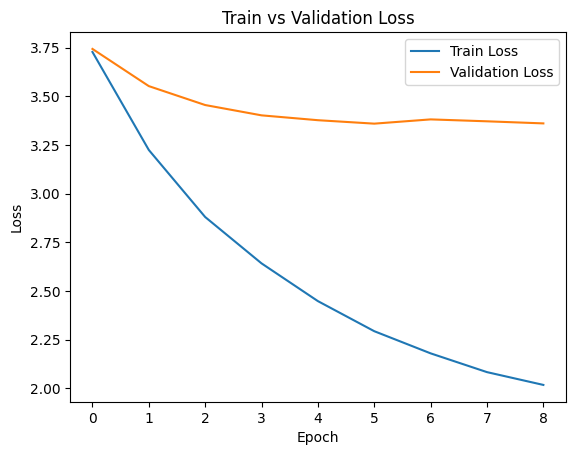

In [24]:
model_layer  = train_model(model_layer)



100%|██████████| 869/869 [00:34<00:00, 25.20it/s]


Epoch 1/20
Train Loss: 5.9068 | Val Loss: 5.3092 | LR: 0.000300
  ✓ Val loss improved to 5.3092, saving checkpoint


100%|██████████| 869/869 [00:34<00:00, 25.51it/s]


Epoch 2/20
Train Loss: 4.9638 | Val Loss: 4.6015 | LR: 0.000300
  ✓ Val loss improved to 4.6015, saving checkpoint


100%|██████████| 869/869 [00:34<00:00, 25.54it/s]


...

Epoch 18/20
Train Loss: 2.2296 | Val Loss: 3.3643 | LR: 0.000300
  ✓ Val loss improved to 3.3643, saving checkpoint


100%|██████████| 869/869 [00:37<00:00, 23.35it/s]


Epoch 19/20
Train Loss: 2.2143 | Val Loss: 3.3733 | LR: 0.000300
  ✗ No improvement for 1/3 epochs


100%|██████████| 869/869 [00:37<00:00, 23.42it/s]


Epoch 20/20
Train Loss: 2.1691 | Val Loss: 3.3812 | LR: 0.000300
  ✗ No improvement for 2/3 epochs

Restored best model with val loss: 3.3643


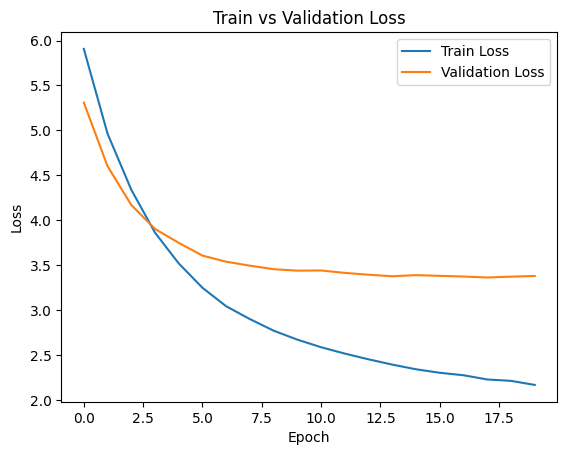

In [52]:
model_rms    = train_model(model_rms)


100%|██████████| 869/869 [00:35<00:00, 24.29it/s]


Epoch 1/20
Train Loss: 5.8375 | Val Loss: 5.1180 | LR: 0.000300
  ✓ Val loss improved to 5.1180, saving checkpoint


100%|██████████| 869/869 [00:36<00:00, 23.88it/s]


Epoch 2/20
Train Loss: 4.7731 | Val Loss: 4.5074 | LR: 0.000300
  ✓ Val loss improved to 4.5074, saving checkpoint


100%|██████████| 869/869 [00:35<00:00, 24.35it/s]


...

Epoch 18/20
Train Loss: 2.2459 | Val Loss: 3.3618 | LR: 0.000300
  ✗ No improvement for 1/3 epochs


100%|██████████| 869/869 [00:38<00:00, 22.79it/s]


Epoch 19/20
Train Loss: 2.2384 | Val Loss: 3.3569 | LR: 0.000300
  ✗ No improvement for 2/3 epochs


100%|██████████| 869/869 [00:37<00:00, 23.13it/s]


Epoch 20/20
Train Loss: 2.1981 | Val Loss: 3.3446 | LR: 0.000300
  ✗ No improvement for 3/3 epochs

Early stopping triggered at epoch 20

Restored best model with val loss: 3.3336


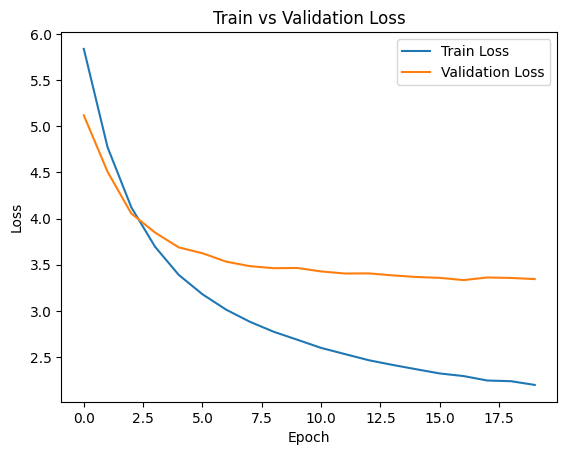

In [58]:
model_prms6  = train_model(model_prms6)


100%|██████████| 869/869 [00:35<00:00, 24.78it/s]


Epoch 1/20
Train Loss: 5.8039 | Val Loss: 5.1327 | LR: 0.000300
  ✓ Val loss improved to 5.1327, saving checkpoint


100%|██████████| 869/869 [00:34<00:00, 24.96it/s]


Epoch 2/20
Train Loss: 4.7219 | Val Loss: 4.4987 | LR: 0.000300
  ✓ Val loss improved to 4.4987, saving checkpoint


100%|██████████| 869/869 [00:34<00:00, 24.88it/s]


...

Epoch 18/20
Train Loss: 2.2350 | Val Loss: 3.3676 | LR: 0.000300
  ✓ Val loss improved to 3.3676, saving checkpoint


100%|██████████| 869/869 [00:37<00:00, 23.20it/s]


Epoch 19/20
Train Loss: 2.2177 | Val Loss: 3.3593 | LR: 0.000300
  ✓ Val loss improved to 3.3593, saving checkpoint


100%|██████████| 869/869 [00:37<00:00, 23.26it/s]


Epoch 20/20
Train Loss: 2.1817 | Val Loss: 3.3635 | LR: 0.000300
  ✗ No improvement for 1/3 epochs

Restored best model with val loss: 3.3593


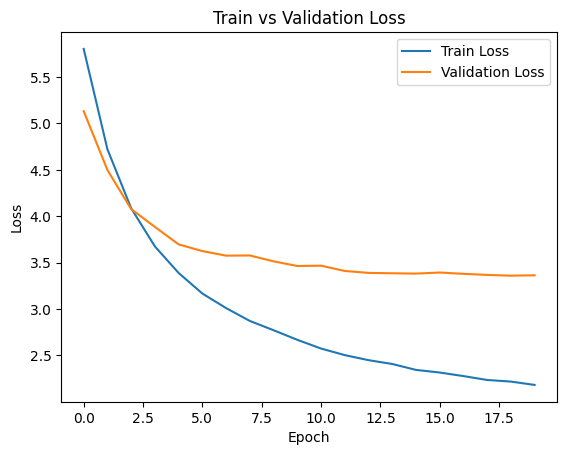

In [65]:
model_prms10 = train_model(model_prms10)

In [25]:
def predict2(model, text):

    model.eval()
    device = next(model.parameters()).device

    ids = encode(text)

    src = torch.tensor(ids).unsqueeze(0).to(device)
    tgt = torch.tensor([[BOS_IDX]]).to(device)

    for _ in range(MAX_LEN):

        with torch.no_grad():
            out = model(src, tgt)

        next_token = out[:, -1].argmax(-1).unsqueeze(1)

        tgt = torch.cat([tgt, next_token], dim=1)

        if next_token.item() == EOS_IDX:
            break

    pred_ids = tgt.squeeze().cpu().tolist()[1:]  # remove BOS
    if EOS_IDX in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(EOS_IDX)]  # truncate at EOS
    return tokenizer.decode(pred_ids).replace(" ", "")

In [ ]:
def predict(model, text, beam_size=5):
    model.eval()
    device = next(model.parameters()).device

    src = torch.tensor(encode(text)).unsqueeze(0).to(device)

    beams = [(0.0, [BOS_IDX])]
    completed = []

    with torch.no_grad():
        for _ in range(MAX_LEN):
            new_beams = []

            for score, ids in beams:
                if ids[-1] == EOS_IDX:
                    completed.append((score, ids))
                    continue

                tgt = torch.tensor([ids]).to(device)
                out = model(src, tgt)
                log_probs = torch.log_softmax(out[:, -1], dim=-1).squeeze(0)

                # Take top beam_size next tokens
                topk_probs, topk_ids = log_probs.topk(beam_size)

                for prob, tok in zip(topk_probs.tolist(), topk_ids.tolist()):
                    new_beams.append((score + prob, ids + [tok]))

            # Keep top beam_size beams by score
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

            # Stop if all beams completed
            if all(ids[-1] == EOS_IDX for _, ids in beams):
                completed.extend(beams)
                break

    if not completed:
        completed = beams

    # Pick best completed sequence
    best_ids = sorted(completed, key=lambda x: x[0], reverse=True)[0][1]
    best_ids = best_ids[1:]  # remove BOS
    if EOS_IDX in best_ids:
        best_ids = best_ids[:best_ids.index(EOS_IDX)]

    return tokenizer.decode(best_ids).replace(" ", "")

In [26]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 59.3 MB/s eta 0:00:00


In [27]:
from jiwer import wer, cer
import numpy as np

In [35]:
def evaluate_model(model, inputs, targets):

    predictions = []

    for inp in inputs:

        pred = predict(model, inp)

        predictions.append(pred)

    clean_targets = [t.strip() for t in targets]
    clean_preds   = [p.strip() for p in predictions]
    cer_score = cer(clean_targets, clean_preds)
    wer_score = wer(clean_targets, clean_preds)


    return cer_score, wer_score

In [ ]:
model_layer = TransformerCorrectionModel(vocab_size, vocab_size, norm_type="layer")
model_layer.load_state_dict(torch.load("model_layernorm.pt"))
model_layer.eval()


model_rms = TransformerCorrectionModel(vocab_size, vocab_size, norm_type="rms")
model_rms.load_state_dict(torch.load("model_rmsnorm.pt"))
model_rms.eval()


model_prms6 = TransformerCorrectionModel(vocab_size, vocab_size, norm_type="prms6")
model_prms6.load_state_dict(torch.load("model_prms6.pt"))
model_prms6.eval()


model_prms10 = TransformerCorrectionModel(vocab_size, vocab_size, norm_type="prms10")
model_prms10.load_state_dict(torch.load("model_prms10.pt"))
model_prms10.eval()

TransformerCorrectionModel(
  (src_embedding): Embedding(8000, 256)
  (tgt_embedding): Embedding(8000, 256)
  (pos_encoding): PositionalEncoding()
  (encoder_layers): ModuleList(
    (0): EncoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_o): Linear(in_features=256, out_features=256, bias=True)
      )
      (ffn): FeedForward(
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
      )
      (norm1): pRMSNorm()
      (norm2): pRMSNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (decoder_layers): ModuleList(
    (0): DecoderLayer(
      (self_attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_featur

In [ ]:
models = {
    "LayerNorm": model_layer,
    "RMSNorm": model_rms,
    "pRMSNorm_6.25": model_prms6,
    "pRMSNorm_10": model_prms10
}

results = {}

for name, model in models.items():

    print("Evaluating:", name)

    cer_score, wer_score = evaluate_model(model, test_x[:500], test_y[:500])

    results[name] = (cer_score, wer_score)

Evaluating: pRMSNorm_10


In [31]:
for model_name, (cer_score, wer_score) in results.items():

    print(f"{model_name}")
    print(f"CER: {cer_score:.4f}")
    print(f"WER: {wer_score:.4f}")
    print("-------------------")

LayerNorm
CER: 0.4394
WER: 0.5528
-------------------


In [37]:
for model_name, (cer_score, wer_score) in results.items():

    print(f"{model_name}")
    print(f"CER: {cer_score:.4f}")
    print(f"WER: {wer_score:.4f}")
    print("-------------------")

LayerNorm
CER: 0.3865
WER: 0.5413
-------------------


In [54]:
for model_name, (cer_score, wer_score) in results.items():

    print(f"{model_name}")
    print(f"CER: {cer_score:.4f}")
    print(f"WER: {wer_score:.4f}")
    print("-------------------")

RMSNorm
CER: 0.3615
WER: 0.5029
-------------------


In [62]:
for model_name, (cer_score, wer_score) in results.items():

    print(f"{model_name}")
    print(f"CER: {cer_score:.4f}")
    print(f"WER: {wer_score:.4f}")
    print("-------------------")

pRMSNorm_6.25
CER: 0.3507
WER: 0.5010
-------------------


In [67]:
for model_name, (cer_score, wer_score) in results.items():

    print(f"{model_name}")
    print(f"CER: {cer_score:.4f}")
    print(f"WER: {wer_score:.4f}")
    print("-------------------")

pRMSNorm_10
CER: 0.3707
WER: 0.5029
-------------------


In [ ]:
tokenizer.save("bpe_tokenizer.json")

In [38]:
torch.save(model_layer.state_dict(), "model_layernorm.pt")




In [57]:
torch.save(model_rms.state_dict(), "model_rmsnorm.pt")


In [63]:
torch.save(model_prms6.state_dict(), "model_prms6.pt")



In [69]:
torch.save(model_prms10.state_dict(), "model_prms10.pt")

In [39]:
for i in range(10):

    inp = test_x[i]
    true = test_y[i]

    print("Input :", inp)
    print("True  :", true)

    for name, model in models.items():
        pred = predict(model, inp)
        print(name, ":", pred)

    print("----------------------------")

Input : सूलमिति
True  : मूलमिति
LayerNorm : सूलमिति
----------------------------
Input : स्पष्टमेव
True  : स्पष्टमेव
LayerNorm : स्पष्टं
----------------------------
Input : स्कुट७य७यः
True  : स्फुटाध्यायः
LayerNorm : स्फुटोयः
----------------------------
Input : ζές
True  : १६९
LayerNorm : तस्मात्
----------------------------
Input : अयमर्थ
True  : अयमर्थः
LayerNorm : अयमर्थः
----------------------------
Input : पुनरपि
True  : पुनरपि
LayerNorm : पुनरपि
----------------------------
Input : द्दितीयफलार्धसंस्कृताङ्गीमात्
True  : द्वितीयफलार्धसंस्कृताद्भौमात्
LayerNorm : फलार्धमात्
----------------------------
Input : मन्दफलमुक्तवत्
True  : मन्दफलमुक्तवत्
LayerNorm : मन्दफलमुक्तवत्
----------------------------
Input : झल्वा
True  : कृत्वा
LayerNorm : हत्वा
----------------------------
Input : तत्सर्वमेवाविझतै
True  : तत्सर्वमेवाविकृते
LayerNorm : तत्सर्वअत्रापि
----------------------------


In [56]:
for i in range(20):

    inp = test_x[i]
    true = test_y[i]

    print("Input :", inp)
    print("True  :", true)

    for name, model in models.items():
        pred = predict(model, inp)
        print(name, ":", pred)

    print("----------------------------")

Input : सूलमिति
True  : मूलमिति
RMSNorm : सूलमिति
----------------------------
Input : स्पष्टमेव
True  : स्पष्टमेव
RMSNorm : स्पष्टमेव
----------------------------
Input : स्कुट७य७यः
True  : स्फुटाध्यायः
RMSNorm : ७
----------------------------
Input : ζές
True  : १६९
RMSNorm : त्रैराशिकम्
----------------------------
Input : अयमर्थ
True  : अयमर्थः
RMSNorm : अयमर्थः
----------------------------
Input : पुनरपि
True  : पुनरपि
RMSNorm : पुनरपि
----------------------------
Input : द्दितीयफलार्धसंस्कृताङ्गीमात्
True  : द्वितीयफलार्धसंस्कृताद्भौमात्
RMSNorm : फलफलसमासार्धं
----------------------------
Input : मन्दफलमुक्तवत्
True  : मन्दफलमुक्तवत्
RMSNorm : मन्दफलमुक्तवत्
----------------------------
Input : झल्वा
True  : कृत्वा
RMSNorm : हत्वा
----------------------------
Input : तत्सर्वमेवाविझतै
True  : तत्सर्वमेवाविकृते
RMSNorm : तत्सर्वमेवा
----------------------------
Input : मध्यम
True  : मध्यमे
RMSNorm : मध्यमे
----------------------------
Input : धनस्टणं
True  : धनमृणं
RMSNorm : धनकेन

In [64]:
for i in range(20):

    inp = test_x[i]
    true = test_y[i]

    print("Input :", inp)
    print("True  :", true)

    for name, model in models.items():
        pred = predict(model, inp)
        print(name, ":", pred)

    print("----------------------------")

Input : सूलमिति
True  : मूलमिति
pRMSNorm_6.25 : मूमिति
----------------------------
Input : स्पष्टमेव
True  : स्पष्टमेव
pRMSNorm_6.25 : स्पष्टमेव
----------------------------
Input : स्कुट७य७यः
True  : स्फुटाध्यायः
pRMSNorm_6.25 : शिष्टं
----------------------------
Input : ζές
True  : १६९
pRMSNorm_6.25 : स्यात्
----------------------------
Input : अयमर्थ
True  : अयमर्थः
pRMSNorm_6.25 : अयमर्थः
----------------------------
Input : पुनरपि
True  : पुनरपि
pRMSNorm_6.25 : पुनरपि
----------------------------
Input : द्दितीयफलार्धसंस्कृताङ्गीमात्
True  : द्वितीयफलार्धसंस्कृताद्भौमात्
pRMSNorm_6.25 : फलमृणं
----------------------------
Input : मन्दफलमुक्तवत्
True  : मन्दफलमुक्तवत्
pRMSNorm_6.25 : मन्दफलमुक्तवत्
----------------------------
Input : झल्वा
True  : कृत्वा
pRMSNorm_6.25 : कृत्वा
----------------------------
Input : तत्सर्वमेवाविझतै
True  : तत्सर्वमेवाविकृते
pRMSNorm_6.25 : तत्सर्वोप
----------------------------
Input : मध्यम
True  : मध्यमे
pRMSNorm_6.25 : मध्यमे
------------------

In [68]:
for i in range(10):

    inp = test_x[i]
    true = test_y[i]

    print("Input :", inp)
    print("True  :", true)

    for name, model in models.items():
        pred = predict(model, inp)
        print(name, ":", pred)

    print("----------------------------")

Input : सूलमिति
True  : मूलमिति
pRMSNorm_10 : मूमिति
----------------------------
Input : स्पष्टमेव
True  : स्पष्टमेव
pRMSNorm_10 : स्पष्टमेव
----------------------------
Input : स्कुट७य७यः
True  : स्फुटाध्यायः
pRMSNorm_10 : स्फुटयुक्ति७
----------------------------
Input : ζές
True  : १६९
pRMSNorm_10 : योजनकर्णः
----------------------------
Input : अयमर्थ
True  : अयमर्थः
pRMSNorm_10 : अयमर्थः
----------------------------
Input : पुनरपि
True  : पुनरपि
pRMSNorm_10 : पुनरपि
----------------------------
Input : द्दितीयफलार्धसंस्कृताङ्गीमात्
True  : द्वितीयफलार्धसंस्कृताद्भौमात्
pRMSNorm_10 : द्वितीयफलार्धमध्यम्
----------------------------
Input : मन्दफलमुक्तवत्
True  : मन्दफलमुक्तवत्
pRMSNorm_10 : मुक्तमुक्तवत्
----------------------------
Input : झल्वा
True  : कृत्वा
pRMSNorm_10 : हत्वा
----------------------------
Input : तत्सर्वमेवाविझतै
True  : तत्सर्वमेवाविकृते
pRMSNorm_10 : तत्सर्वविहते
----------------------------
